In [2]:
import os

DATA_PATH = r'C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET'
SUPP_AUDIO_PATH = r'C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio'
SAVE_PATH = r'C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET\save'
PACKAGE_PATH = '/content/drive/MyDrive/M2_MOBI/PACKAGES'
MODEL_PATH = r'C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET\model'


In [ ]:
# general packages
import warnings
warnings.filterwarnings(action='ignore')
import os
import sys
import time
import math
from pathlib import Path        # to support linux and windows paths
import random                   # to provide random numbers
import re                       # to perform regular expression matching
import json                     # to read json file
from glob import glob           # to collect files in a directory and subdirectory
import datetime
import seaborn as sns


# basic packages
import numpy as np              # adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import pandas as pd             # library providing high-performance, easy-to-use data structures and data analysis tools (Dataframe)
import matplotlib.pyplot as plt # a comprehensive library for creating static, animated, and interactive visualizations
plt.rcParams.update({'figure.max_open_warning': 0})
plt.style.use("default")

# audio package
import librosa
import librosa.display

# scikit-learn package (machine learning)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Scikit-Maad (ecoacoustics functions) package
from maad import sound
from maad import util

import gdown

###### BIRDNET #######
# go to the directory
os.chdir('C:/BirdNET-Analyzer')
# import all functions to use BirdNET that are contained in analyze.py
from analyze import *


In [14]:
def plot_map_nbspecies_by_time (
                            dataframe,
                            time_resolution = "30T",
                            time_range = ["00:00", "23:59"],
                            start_hour = "00:00",
                            cb_legend = None,
                            **kwargs,
                            ) :
  """

  Parameters
  ----------
  dataframe : TYPE
     DESCRIPTION.
  disp_column : TYPE
      DESCRIPTION.
  time_resolution : TYPE, optional
      DESCRIPTION. The default is "30T".
  time_range : TYPE, optional
      DESCRIPTION. The default is ["00:00", "23:59"].
  start_hour : TYPE, optional
      DESCRIPTION. The default is "12:00".
  **kwargs : TYPE
      DESCRIPTION.
   : TYPE
      DESCRIPTION.

  Returns
  -------
  fig : TYPE
      DESCRIPTION.
  ax : TYPE
      DESCRIPTION.

  """
  sns.set_theme("paper")

  # test if dataframe is not a pd.DataFrame
  if isinstance(dataframe, pd.DataFrame) == False:
      print("***WARNING*** dataframe must be a valide pandas dataframe")
      return

  # copy the dataframe
  df = dataframe.copy()

  # create a column with the date from the filname
  try :
    df['Date'] = [datetime.strptime(d[9:], '%Y%m%d_%H%M%S') for d in df.filename]
  except :
    print("***WARNING*** dataframe must have a valid filename (SM4 format)"+
          "that can be converted in Datetime type")
  # Date into Datetime type
  df_date = pd.to_datetime(df.Date)
  # round Date
  df.Date = df_date.round(time_resolution) # "30T"
  # set index as DatetimeIndex
  df = df.set_index(pd.DatetimeIndex(df.Date))
  # remove Date column
  df.drop('Date', axis=1, inplace=True)
  # sort dataframe by date
  df = df.sort_index(axis=0)

  # Extract hour and minute
  df['time'] = df.index.strftime("%H:%M")

  # add a column count for the summation
  df['count'] = 1

  # create a matrix with week as columns and time (hour) as rows
  df_mean = df.groupby(['time', 'label'])['count'].aggregate('sum').unstack()

  # Create a list of unique index of type 'hour'
  x_label = pd.date_range(time_range[0], time_range[1], freq=time_resolution).strftime('%H:%M')
  x_label = x_label.values
  # create an prefilled dataframe with all weeks and time
  df2 = pd.DataFrame(index=x_label,
                     columns= list(df_mean),
                     dtype = 'float')
  df2.reset_index(inplace=True)
  df2 = df2.rename(columns={"index":"time"})
  df2.set_index("time", inplace=True)
  df2.columns.name='week'

  for idx, row in df_mean.iterrows() :
    df2.loc[idx] = row

  df_mean=df2

  # shift the time to start at start_hour and finish at start_hour, in order to center
  # the graph at start_hour + 12h
  df_part1 = df_mean[df_mean.index >= start_hour]
  df_part2 = df_mean[df_mean.index < start_hour]
  df_part2.sort_index(inplace=True)
  df = pd.concat([df_part1,df_part2])

  # Get the list of unique index of type 'hour'
  x_label = [i + j for i, j in zip(map(str, df.index.values), [" "] * len(df))]

  # plot
  vmin = kwargs.pop("vmin", np.nanpercentile(df,1))
  vmax = kwargs.pop("vmax", np.nanpercentile(df,99))
  cmap = kwargs.pop("cmap", "RdPu")

  fig = plt.figure(figsize=(len(df)*0.33*0.75, len(list(df))*0.26*0.75))
  ax = fig.add_subplot(111)
  caxes = ax.matshow(df.transpose(),
                     interpolation = "None",
                     aspect="auto",
                     cmap = cmap,
                     vmin = vmin,
                     vmax = vmax,
                     )
  if cb_legend is None :
    fig.colorbar(caxes, shrink=0.75, label='count')
  else:
    fig.colorbar(caxes, shrink=0.75, label=cb_legend)    # Set ticks on both sides of axes on
  ax.tick_params(which='major', axis="x", bottom=False, top=False,
                 labelbottom=True, labeltop=False)
  ax.tick_params(which='minor', axis="x", length = 0)
  # We want to show all ticks...
  ax.set_yticks(np.arange(len(df.columns)))
  ax.set_xticks(np.arange(len(x_label)))
  # ... and label them with the respective list entries
  ax.set_yticklabels(df.columns)
  ax.set_xticklabels(x_label)

  # Minor ticks
  ax.set_xticks(np.arange(-0.5, len(df.index), 1), minor=True)
  ax.set_yticks(np.arange(-0.5, len(list(df)), 1), minor=True)

  # Gridlines based on minor ticks
  ax.grid(which='major', color='w', linestyle='-', linewidth=0)
  ax.grid(which='minor', color='w', linestyle='-', linewidth=1)

  # add title to the axis
  ax.set_xlabel("Time")
  ax.set_ylabel("Species")

  # Rotate the tick labels and set their alignment.
  plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=10)
  plt.setp(ax.get_xticklabels(), rotation=90, ha="center", fontsize=10)
  plt.tight_layout()
  plt.show()

  return fig, ax


In [5]:
# grab all audio recording files in the dataset
filelist = glob(DATA_PATH+'/**/*.wav', recursive = True)

# print the number of audio recordings
print("The number of 1 min audio recordings is %d" %len(filelist))

The number of 1 min audio recordings is 1110


In [18]:
# go the parent directory
DATA_PATH = os.path.dirname(DATA_PATH)

# test if the dataset already exists
UNZIP_PATH = DATA_PATH + '/BOREAL_OWL_DATASET'
if os.path.exists(UNZIP_PATH) :
  print("THE DIRECTORY WITH THE DATASET ALREADY EXISTS : {}".format(UNZIP_PATH))
else :
  # execute shell command to unzip (faster than Python zip functions)
  URL = 'https://drive.google.com/uc?export=download&id=1HkA8ZvVMa2YmHdJ7MrzV4YWnuVkDuQEf'
  UNZIP_PATH = DATA_PATH
  TEMP_PATH  = DATA_PATH + '/tmp.zip'

  gdown.download(URL, TEMP_PATH, False)

  !unzip -u $TEMP_PATH -d $UNZIP_PATH
  !rm $TEMP_PATH

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1HkA8ZvVMa2YmHdJ7MrzV4YWnuVkDuQEf
From (redirected): https://drive.google.com/uc?export=download&id=1HkA8ZvVMa2YmHdJ7MrzV4YWnuVkDuQEf&confirm=t&uuid=ca98ad18-63a3-45e0-9ba8-23a0dd8e73d4
To: C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\tmp.zip
100%|██████████| 104M/104M [01:00<00:00, 1.71MB/s] 
'unzip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.
'rm' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [20]:
### découper la bdd de XC

from pydub import AudioSegment
import math
import os

# Paramètres
input_folder = SUPP_AUDIO_PATH  # Remplace par le chemin de ton dossier
output_folder = "output_segments"
segment_length = 4 * 1000  # 4 secondes en millisecondes

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.lower().endswith(".mp3"):
        input_path = os.path.join(input_folder, filename)
        # Crée un sous-dossier pour chaque fichier source
        base_name = os.path.splitext(filename)[0]
        file_output_folder = os.path.join(output_folder, base_name)
        os.makedirs(file_output_folder, exist_ok=True)
        
        audio = AudioSegment.from_mp3(input_path)
        duration = len(audio)
        num_segments = math.ceil(duration / segment_length)
        
        for i in range(num_segments):
            start = i * segment_length
            end = min(start + segment_length, duration)
            segment = audio[start:end]
            segment.export(
                os.path.join(file_output_folder, f"{base_name}_segment_{i+1:03d}.mp3"),
                format="mp3"
            )
        print(f"{filename} découpé en {num_segments} segments dans {file_output_folder}")

print("Tous les fichiers ont été traités.")


XC569359.mp3 découpé en 13 segments dans output_segments\XC569359
XC569361.mp3 découpé en 22 segments dans output_segments\XC569361
XC569364.mp3 découpé en 23 segments dans output_segments\XC569364
XC730569.mp3 découpé en 45 segments dans output_segments\XC730569
XC730570.mp3 découpé en 17 segments dans output_segments\XC730570
XC738850.mp3 découpé en 17 segments dans output_segments\XC738850
XC738857.mp3 découpé en 16 segments dans output_segments\XC738857
XC738863.mp3 découpé en 213 segments dans output_segments\XC738863
XC738865.mp3 découpé en 23 segments dans output_segments\XC738865
XC738878.mp3 découpé en 41 segments dans output_segments\XC738878
XC911307.mp3 découpé en 20 segments dans output_segments\XC911307
XC959776.mp3 découpé en 12 segments dans output_segments\XC959776
XC959777.mp3 découpé en 4 segments dans output_segments\XC959777
XC959778.mp3 découpé en 18 segments dans output_segments\XC959778
XC959971.mp3 découpé en 2 segments dans output_segments\XC959971
Tous les fi

In [85]:
### transformer .mp3 en .wav
import os
from pydub import AudioSegment

# Dossier contenant les MP3
input_folder = DATA_PATH+"/MARMOTA_MARMOTA_DATASET/TEST/Marmota marmota_Alpine Marmot"
# Dossier de sortie pour les WAV
output_folder = input_folder
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.lower().endswith(".mp3"):
        mp3_path = os.path.join(input_folder, filename)
        wav_filename = os.path.splitext(filename)[0] + ".wav"
        wav_path = os.path.join(output_folder, wav_filename)
        # Conversion
        audio = AudioSegment.from_mp3(mp3_path)
        audio.export(wav_path, format="wav")
        print(f"{filename} converti en {wav_filename}")

print("Conversion terminée.")


XC730570_segment_001.mp3 converti en XC730570_segment_001.wav
XC730570_segment_002.mp3 converti en XC730570_segment_002.wav
XC730570_segment_005.mp3 converti en XC730570_segment_005.wav
XC730570_segment_006.mp3 converti en XC730570_segment_006.wav
XC730570_segment_015.mp3 converti en XC730570_segment_015.wav
XC730570_segment_016.mp3 converti en XC730570_segment_016.wav
XC730570_segment_017.mp3 converti en XC730570_segment_017.wav
XC911307_segment_012.mp3 converti en XC911307_segment_012.wav
XC911307_segment_013.mp3 converti en XC911307_segment_013.wav
XC911307_segment_017.mp3 converti en XC911307_segment_017.wav
XC911307_segment_020.mp3 converti en XC911307_segment_020.wav
XC959776_segment_003.mp3 converti en XC959776_segment_003.wav
XC959776_segment_005.mp3 converti en XC959776_segment_005.wav
XC959776_segment_007.mp3 converti en XC959776_segment_007.wav
XC959776_segment_011.mp3 converti en XC959776_segment_011.wav
XC959778_segment_007.mp3 converti en XC959778_segment_007.wav
XC959778

In [7]:
import wave
import os

folder = r"C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\BOREAL_OWL_DATASET\TRAIN\background"

for filename in os.listdir(folder):
    if filename.lower().endswith(".wav"):
        filepath = os.path.join(folder, filename)
        with wave.open(filepath, 'rb') as wf:
            nchannels = wf.getnchannels()
            sampwidth = wf.getsampwidth()
            framerate = wf.getframerate()
            print(f"{filename}: {nchannels} canaux, {sampwidth*8} bits, {framerate} Hz")


S4A03895_20191019_230000_7.wav: 2 canaux, 16 bits, 44100 Hz
S4A03998_20180726_214500_5.wav: 2 canaux, 16 bits, 44100 Hz
S4A04430_20180813_040000_6.wav: 2 canaux, 16 bits, 44100 Hz
S4A04430_20190322_210000_6.wav: 2 canaux, 16 bits, 44100 Hz
S4A04430_20190322_231500_6.wav: 2 canaux, 16 bits, 44100 Hz
S4A04430_20190322_233000_7.wav: 2 canaux, 16 bits, 44100 Hz
S4A04430_20190323_061500_5.wav: 2 canaux, 16 bits, 44100 Hz
S4A04430_20190914_223000_4.wav: 2 canaux, 16 bits, 44100 Hz
S4A04430_20201008_233000_0.wav: 2 canaux, 16 bits, 44100 Hz
S4A10754_20210313_034500_3.wav: 2 canaux, 16 bits, 44100 Hz
S4A10754_20210513_003000_10.wav: 2 canaux, 16 bits, 44100 Hz
S4A10754_20211013_040000_3.wav: 2 canaux, 16 bits, 44100 Hz
S4A10754_20211013_040000_9.wav: 2 canaux, 16 bits, 44100 Hz
S4A10754_20220221_224500_5.wav: 2 canaux, 16 bits, 44100 Hz
S4A10754_20220413_231500_3.wav: 2 canaux, 16 bits, 44100 Hz
S4A10754_20220413_231500_9.wav: 2 canaux, 16 bits, 44100 Hz
S4A10754_20220414_020000_5.wav: 2 canau

1. Entrainement sur données de XC

In [86]:
!python train.py --i "$DATA_PATH/MARMOTA_MARMOTA_DATASET/TRAIN" --o "$MODEL_PATH/custom_birdnet_marmota_marmota_sorted" --mixup --hidden_units 16 --dropout 0.33 --crop_mode segments --crop_overlap 2

Loading training data...



 - loading 'Marmota marmota_Alpine Marmot':   0%|          | 0/42 [00:00<?, ?f/s]WARNING:tensorflow:From c:\Users\phano\anaconda3\envs\esresnextfbsp310\lib\site-packages\keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.






INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
IWARNINNFG: AOt:I tCreateNFO:dempt  ing tCoTen ussoe a derFrlegatloweaet  Lthiedta TentesorFl  onlXoyN suNPACK dppoelegaterts for CPU.
 w Lite XstatiNNPAc-CK delsiegatezed for  tensors with CPU.
a graph that has WAdynamRic-sizedNING te: nAsors (tensor#t1tempting8 to us7eW is a dy a denamic-sizelAegate thdRNI tenNaGt os: oAttermpnly) supp.
toinrts statg to use a delegate that only supports static-sizeic-sizedd  tensors with a tgraph that heas dynnasors with a mic-sigzeraph that has dynad mten


...Done. Loaded 177 training samples and 1 labels.
Building model...
...Done.
Training model...
Training on 141 samples, validating on 36 samples.
Epoch 1/50

5/5 [==============================] - 1s 61ms/step - loss: 0.5763 - AUPRC: 0.8275 - AUROC: 0.7569 - val_loss: 0.3067 - val_AUPRC: 1.0000 - val_AUROC: 1.0000
Epoch 2/50

5/5 [==============================] - 0s 10ms/step - loss: 0.3310 - AUPRC: 0.9746 - AUROC: 0.9594 - val_loss: 0.1753 - val_AUPRC: 1.0000 - val_AUROC: 1.0000
Epoch 3/50

5/5 [==============================] - 0s 9ms/step - loss: 0.2000 - AUPRC: 0.9973 - AUROC: 0.9962 - val_loss: 0.0994 - val_AUPRC: 1.0000 - val_AUROC: 1.0000
Epoch 4/50

5/5 [==============================] - 0s 9ms/step - loss: 0.1349 - AUPRC: 0.9990 - AUROC: 0.9987 - val_loss: 0.0600 - val_AUPRC: 1.0000 - val_AUROC: 1.0000
Epoch 5/50

5/5 [==============================] - 0s 9ms/step - loss: 0.0970 - AUPRC: 0.9975 - AUROC: 0.9962 - val_loss: 0.0419 - val_AUPRC: 1.0000 - val_AUROC: 1.0000
Epoch

In [5]:
#@title  { run: "auto", vertical-output: true, form-width: "1000px", display-mode: "both" }
###### BirdNET parameters
# Overlap in seconds between extracted spectrograms. Values in [0.0, 2.9]. Defaults tp 0.0.
OVLP = 1.5                #@param {type:"slider", min:0.0, max:2.9, step:0.1}
# Detection sensitivity; Higher values result in higher sensitivity. Values in [0.5, 1.5]. Defaults to 1.0.
SENSITIVITY = 1         #@param {type:"slider", min:0.5, max:1.5, step:0.1}
# Minimum confidence threshold. Values in [0.01, 0.99]. Defaults to 0.1.
MIN_CONFIDENCE = 0.1   #@param {type:"slider", min:0.01, max:0.99, step:0.01}



2. Vérification sur 1 fichier audio réel

In [16]:
audio_filename = 'VAL4_20220630_100000.wav' #@param {type: "string"}
birdnet_filename = audio_filename[:-4] + '.BirdNET.results.csv'
# annotations_filename = audio_filename[:-4] + '.txt'

In [7]:
!python analyze.py --classifier "$MODEL_PATH/custom_birdnet_marmota_marmota_sorted.tflite" --i "$SUPP_AUDIO_PATH/Audio_ech/VAL4/$audio_filename" --o "$SAVE_PATH" --min_conf $MIN_CONFIDENCE --rtype csv


usage: analyze.py [-h] [--i I] [--o O] [--lat LAT] [--lon LON] [--week WEEK]
                  [--slist SLIST] [--sensitivity SENSITIVITY]
                  [--min_conf MIN_CONF] [--overlap OVERLAP]
                  [--rtype {table,audacity,r,kaleidoscope,csv} [{table,audacity,r,kaleidoscope,csv} ...]]
                  [--combine_results | --no-combine_results]
                  [--threads THREADS] [--batchsize BATCHSIZE]
                  [--locale LOCALE] [--sf_thresh SF_THRESH]
                  [--classifier CLASSIFIER] [--fmin FMIN] [--fmax FMAX]
                  [--skip_existing_results]
analyze.py: error: argument --min_conf: invalid float value: '$MIN_CONFIDENCE'


In [17]:
# read the csv file where the result of the BirdNET analysis is stored
df_rois_birdnet = pd.read_csv(SAVE_PATH + '/' + birdnet_filename, sep=',' )
df_rois_birdnet.head()

,Start (s),End (s),Scientific name,Common name,Confidence,File
0,0.0,3.0,Marmota marmota,Alpine Marmot,0.9491,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...
1,3.0,6.0,Marmota marmota,Alpine Marmot,0.9322,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...
2,6.0,9.0,Marmota marmota,Alpine Marmot,0.9885,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...
3,9.0,12.0,Marmota marmota,Alpine Marmot,0.9749,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...
4,12.0,15.0,Marmota marmota,Alpine Marmot,0.9784,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...


In [21]:
# create the scientific code from the scientific name and add it as a label column
df_rois_birdnet['label'] = [((x.split(" ", 1)[0][0:3]).lower()+(x.split(" ", 1)[1][0:3]).lower()) for x in df_rois_birdnet['Scientific name']]

# print informations about the detected birdsongs
print ('Total number of marmot calls : %2.0f' %len(df_rois_birdnet))
print ('Number of different species : %2.0f' %len(np.unique(df_rois_birdnet['label'])))
print ('list of species detected : %s' %df_rois_birdnet['label'].unique())

Total number of marmot calls : 20
Number of different species :  1
list of species detected : ['marmar']


In [22]:
df_rois_birdnet

,Start (s),End (s),Scientific name,Common name,Confidence,File,min_t,max_t,min_f,max_f,min_y,min_x,max_y,max_x,label
0,0.0,3.0,Marmota marmota,Alpine Marmot,0.9491,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,0.010667,3.000000,2000,4000,43,0,85,280,marmar
1,3.0,6.0,Marmota marmota,Alpine Marmot,0.9322,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,3.000000,6.000000,2000,4000,43,280,85,561,marmar
2,6.0,9.0,Marmota marmota,Alpine Marmot,0.9885,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,6.000000,9.000000,2000,4000,43,561,85,843,marmar
3,9.0,12.0,Marmota marmota,Alpine Marmot,0.9749,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,9.000000,12.000000,2000,4000,43,843,85,1124,marmar
4,12.0,15.0,Marmota marmota,Alpine Marmot,0.9784,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,12.000000,15.000000,2000,4000,43,1124,85,1405,marmar
5,15.0,18.0,Marmota marmota,Alpine Marmot,0.9310,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,15.000000,18.000000,2000,4000,43,1405,85,1686,marmar
6,18.0,21.0,Marmota marmota,Alpine Marmot,0.9909,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,18.000000,21.000000,2000,4000,43,1686,85,1968,marmar
7,21.0,24.0,Marmota marmota,Alpine Marmot,0.9849,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,21.000000,24.000000,2000,4000,43,1968,85,2249,marmar
8,24.0,27.0,Marmota marmota,Alpine Marmot,0.5197,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,24.000000,27.000000,2000,4000,43,2249,85,2530,marmar
9,27.0,30.0,Marmota marmota,Alpine Marmot,0.9937,C:\Users\phano\Documents\_MoBI 2024\LECA2025\A...,27.000000,30.000000,2000,4000,43,2530,85,2811,marmar


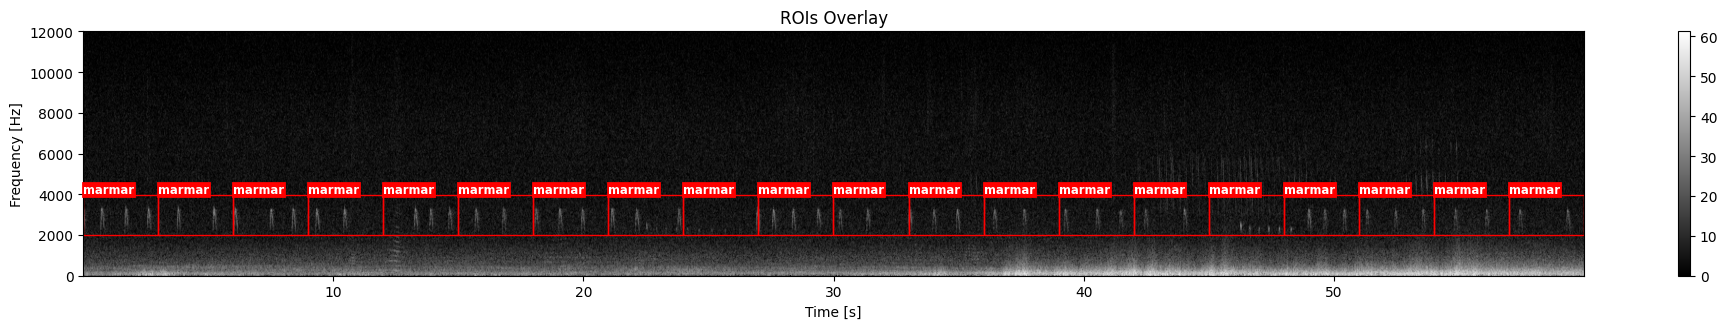

In [24]:
if len(df_rois_birdnet) >0 :

  # add new columns
  df_rois_birdnet['min_t'] = df_rois_birdnet['Start (s)']
  df_rois_birdnet['max_t'] = df_rois_birdnet['End (s)']
  df_rois_birdnet['min_f'] = [2000 for f in range(0, len(df_rois_birdnet))]
  df_rois_birdnet['max_f'] = df_rois_birdnet['min_f']+ [2000 for f in range(0, len(df_rois_birdnet))]

  # Load the 1 min audio recording
  s, fs = sound.load(SUPP_AUDIO_PATH + '/Audio_ech/VAL4/' + audio_filename)

  # Compute the spectrogram of the audio recording
  Sxx_power, tn, fn, ext = sound.spectrogram(s, fs, nperseg=1024, noverlap=1024//2, flims=[0,12000])

  # format dataframe df_rois in order to convert time and frequency into pixels
  df_rois_birdnet = util.format_features(df_rois_birdnet, tn, fn)

  # Convert the power spectrogram into dB, add dB_max which is the maximum decibel
  # range when quantification bit is 16bits and display the result
  dB_max = 96   # Set the maximal value in dB
  Sxx_db = util.power2dB(Sxx_power) + dB_max

  # overlay bounding box on the original spectrogram
  ax1, fig1 = util.overlay_rois(Sxx_db,
                                df_rois_birdnet,
                                textbox_label = True,
                                edge_color = 'red',
                                **{'vmin':0,'vmax':np.max(Sxx_db),'extent':ext})

(<Axes: xlabel='Time [s]', ylabel='Frequency [Hz]'>,
 <Figure size 1000x500 with 2 Axes>)

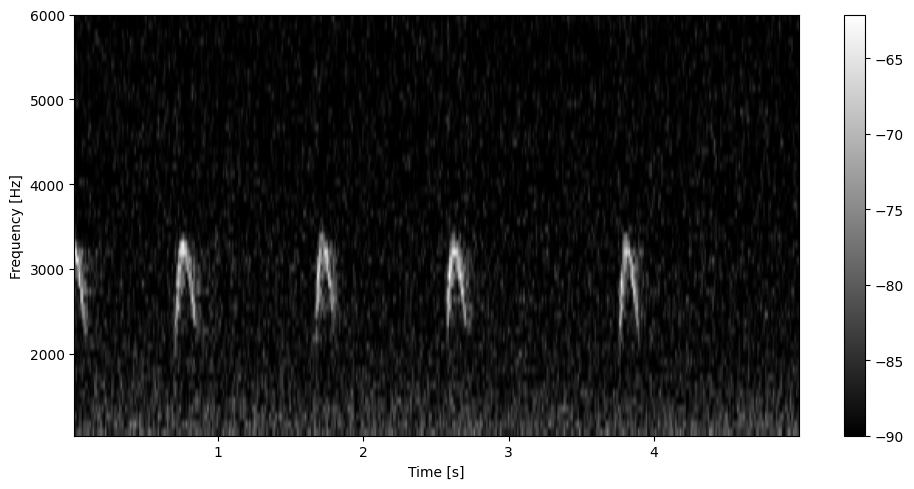

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from maad import sound, features
from maad.util import power2dB, plot2d
from skimage import transform
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import NMF


s, fs = sound.load(SUPP_AUDIO_PATH + '/Audio_ech/VAL4/' + audio_filename)
Sxx, tn, fn, ext = sound.spectrogram(s, fs, nperseg=1024, noverlap=0.75*1024, flims=[1000,6000], tlims=[0,5],window="hamming")

Sxx_db = power2dB(Sxx, db_range=90)
Sxx_db = transform.rescale(Sxx_db, 0.5, anti_aliasing=True, channel_axis=None)  # rescale for faster computation # multichannel=False change by  channel_axis=None
plot2d(Sxx_db, figsize=(4,10), extent=ext)

In [18]:
shape_im, params = features.shape_features_raw(Sxx_db, resolution='low')

# Format the output as an array for decomposition
X = np.array(shape_im).reshape([len(shape_im), Sxx_db.size]).transpose()

# Decompose signal using non-negative matrix factorization
Y = NMF(n_components=3, init='random', random_state=0).fit_transform(X)

In [19]:
Y = MinMaxScaler(feature_range=(0,1)).fit_transform(Y)
intensity = 1 - (Sxx_db - Sxx_db.min()) / (Sxx_db.max() - Sxx_db.min())
plt_data = Y.reshape([Sxx_db.shape[0], Sxx_db.shape[1], 3])
plt_data = np.dstack((plt_data, intensity))

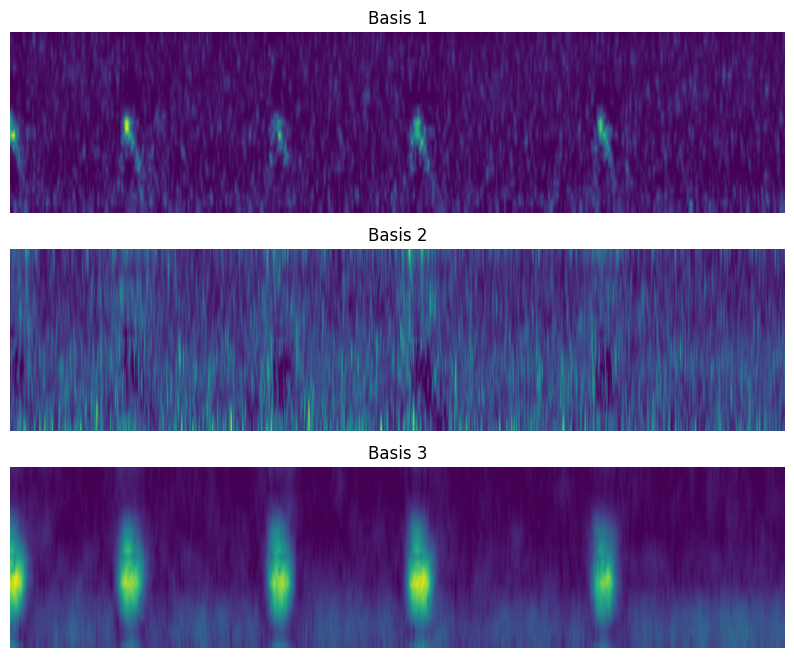

In [40]:
fig, axes = plt.subplots(3,1, figsize=(10,8))
for idx, ax in enumerate(axes):
    ax.imshow(plt_data[:,:,idx], origin='lower', aspect='auto',
              interpolation='bilinear')
    ax.set_axis_off()
    ax.set_title('Basis ' + str(idx+1))

Text(0.5, 1.0, 'False-color spectrogram')

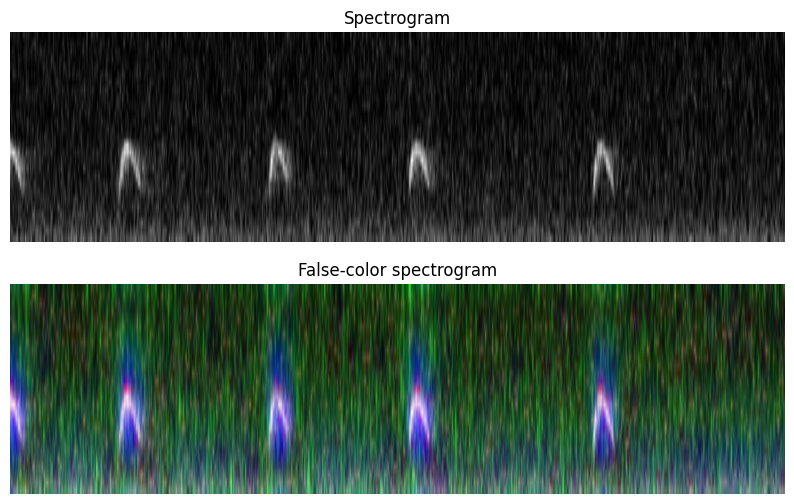

In [21]:
fig, ax = plt.subplots(2,1, figsize=(10,6))
ax[0].imshow(Sxx_db, origin='lower', aspect='auto', interpolation='bilinear', cmap='gray')
ax[0].set_axis_off()
ax[0].set_title('Spectrogram')
ax[1].imshow(plt_data, origin='lower', aspect='auto', interpolation='bilinear')
ax[1].set_axis_off()
ax[1].set_title('False-color spectrogram')

In [1]:
dB_max = 96
chunk = 3

Sxx_power, tn, fn, ext = sound.spectrogram(
   x=s,
   fs=fs,
   nperseg=1024,
   noverlap=1024//2,
   flims=[1000,6000],
   tlims=[chunk*10,(chunk+1)*10]
   )

# Convert the power spectrogram into dB, add dB_max which is the maximum decibel
# range when quantification bit is 16bits and display the result
Sxx_db = power2dB(Sxx_power) + dB_max

plot2d(
   im=Sxx_db,figsize=(4,10),
   **{
      'vmin':0,
      'vmax':dB_max,
      'extent':ext
      }
   )

NameError: name 'sound' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from maad import sound, rois, features
from maad.util import (
   power2dB, plot2d, format_features, read_audacity_annot,
   overlay_rois, overlay_centroid
   )
# First we remove the stationary background in order to increase the contrast [1]
# Then we convert the spectrogram into dB
Sxx_power_noNoise= sound.median_equalizer(
   Sxx=Sxx_power,
   display=True,
   figsize=(4,10),
   **{'extent':ext}
   )
Sxx_db_noNoise = power2dB(Sxx_power_noNoise)

# Then we smooth the spectrogram in order to facilitate the creation of masks as
# small sparse details are merged if they are close to each other
Sxx_db_noNoise_smooth = sound.smooth(
   Sxx=Sxx_db_noNoise,
   std=0.5,
   display=True,
   savefig=None,
   figsize=(4,10),
   **{
      'vmin':0,
      'vmax':dB_max,
      'extent':ext
      }
   )

# Then we create a mask (i.e. binarization of the spectrogram) by using the
# double thresholding technique
im_mask = rois.create_mask(
   im=Sxx_db_noNoise_smooth,
   mode_bin='relative',
   bin_std=8,
   bin_per=0.5,
   verbose=False,
   display=True,
   figsize=(4,10)
   )

# Finaly, we put together pixels that belong to the same acoustic event, and
# remove very small events (<=25 pixel²)
im_rois, df_rois = rois.select_rois(
   im_bin=im_mask,
   min_roi=100,
   max_roi=None,
   display= True,
   figsize=(4,10),
   **{'extent':ext}
   )

# format dataframe df_rois in order to convert pixels into time and frequency
df_rois = format_features(
   df=df_rois,
   tn=tn,
   fn=fn
   )

# overlay bounding box on the original spectrogram
ax0, fig0 = overlay_rois(
   im_ref=Sxx_db,
   rois=df_rois,
   figsize=(4,10),
   **{
      'vmin':0,
      'vmax':dB_max,
      'extent':ext
      }
   )

# Compute centroids
df_centroid = features.centroid_features(
   Sxx=Sxx_db,
   rois=df_rois,
   im_rois=im_rois
   )

# format dataframe df_centroid in order to convert pixels into time and frequency
df_centroid = format_features(
   df=df_centroid,
   tn=tn,
   fn=fn
   )

# overlay centroids on the original spectrogram
ax0, fig0 = overlay_centroid(
   im_ref=Sxx_db,
   centroid=df_centroid,
   savefig=None,
   figsize=(4,10),
   **{
      'vmin':0,
      'vmax':dB_max,
      'extent':ext,
      'ms':4,
      'marker':'+',
      'color':'red',
      'fig':fig0,
      'ax':ax0
      }
   )

NameError: name 'Sxx_power' is not defined

In [1]:
df_rois

NameError: name 'df_rois' is not defined

3. Matrice de confusion sur test

In [94]:
!python analyze.py --classifier "$MODEL_PATH/custom_birdnet_marmota_marmota_sorted.tflite" --i "$DATA_PATH/MARMOTA_MARMOTA_DATASET/TEST" --o "$SAVE_PATH/CUSTOM_BIRDNET_SORTED/MARMOTA_MARMOTA_DATASET/TEST" --sensitivity $SENSITIVITY --min_conf 0.1 --rtype csv

Species list contains 1 species
Found 62 files to analyze
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET/MARMOTA_MARMOTA_DATASET/TEST\Marmota marmota_Alpine Marmot\XC569359_segment_001.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET/MARMOTA_MARMOTA_DATASET/TEST\Marmota marmota_Alpine Marmot\XC569359_segment_010.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET/MARMOTA_MARMOTA_DATASET/TEST\Marmota marmota_Alpine Marmot\XC730570_segment_002.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET/MARMOTA_MARMOTA_DATASET/TEST\Marmota marmota_Alpine Marmot\XC730570_segment_006.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET/MARMOTA_MARMOTA_DATASET/TEST\Marmota marmota_Alpine Marmot\XC730570_segment_015.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\MarmotNET/MARMOTA_MARMOTA_DATASET/TEST\Marmota marmota_Alpine Marmot\XC911307_segment_001.wav
Finished C:\Users\phano\Documents\_MoBI 2024\LEC








INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO: INFO:Creat Createed Td TensorFensolow LirWAte XNNRPACFNlow Lite XNNPACK dIKN G:d Attempteelegate legiate ffnorg  ortCP UC.o
 uPU.
se a delegate that only supports static-sized tensors with a graph that has dynamic-sized tensors (tensor#189 is a dynamic-sized tensor).
zed tensors (tensor#189 is a dynamic-sized tensor).
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [95]:
#@title  { run: "auto", form-width: "1000px" }
# Minimum confidence threshold. Values in [0.01, 0.99]. Defaults to 0.1.
min_confidence = 0.5    #@param {type:"slider", min:0.01, max:0.99, step:0.01}

In [96]:
# to manipulate date and time
from datetime import datetime
from pathlib import Path

# grab all birdnet output files
filelist = glob(SAVE_PATH+'/CUSTOM_BIRDNET_SORTED/MARMOTA_MARMOTA_DATASET/TEST/'+'/**/*.csv', recursive = True)

# remove groundtruth.csv from the list
filelist = [x for x in filelist if 'groundtruth.csv' not in x]

# create a dataframe with all anotations files in the directory
# add new columns similar to the output of BirdNET in order to compate both
# results
df_raw_birdnet = pd.DataFrame()

# list of columns
cols = ['filename', 'Start (s)','End (s)','Confidence', 'label' ]

for file in filelist:
  # read the csv file associated with the audio file
  df_rois = pd.read_csv(file, sep=',' )

  # if there is a detection, add a column with the filename and a column with the label
  if len(df_rois) > 0 :
    df_rois['filename'] = Path(file).parts[-1][:-20] + '.wav'
    if df_rois['Confidence'].max() > min_confidence :
      df_rois['label'] = [((x.split(" ", 1)[0][0:3]).lower()+(x.split(" ", 1)[1][0:3]).lower()) for x in df_rois['Scientific name']]
    else :
      df_rois['label'] = 'none'

  # else add a column with the filename and set the other columns to NaN
  else :
    df_rois = pd.DataFrame(columns=cols, dtype=float)
    df_rois.loc[0, 'filename'] = Path(file).parts[-1][:-20]+ '.wav'
    df_rois.loc[0, 'Start (s)'] = 0
    df_rois.loc[0, 'End (s)']   = 6
    df_rois.loc[0, 'label']     = 'none'
    df_rois.loc[0, 'Confidence']= 1

  # reorder the columns
  df_rois = df_rois[['filename',
                      'Start (s)',
                      'End (s)',
                      'Confidence',
                      'label'
                      ]]

  # add the annotations of the current file into the big dataframe with all
  # annotations
  df_raw_birdnet = pd.concat([df_raw_birdnet, df_rois], axis=0, ignore_index=True)

# display the first rows of the dataframe
df_raw_birdnet.head(10)


,filename,Start (s),End (s),Confidence,label
0,XC569359_segment_009.wav,0.0,3.0,0.6979,marmar
1,XC738850_segment_003.wav,0.0,6.0,1.0000,none
2,XC738850_segment_011.wav,0.0,6.0,1.0000,none
3,XC911307_segment_004.wav,0.0,6.0,1.0000,none
4,XC911307_segment_005.wav,0.0,6.0,1.0000,none
5,XC911307_segment_006.wav,0.0,6.0,1.0000,none
6,XC911307_segment_011.wav,0.0,6.0,1.0000,none
7,XC911307_segment_014.wav,0.0,6.0,1.0000,none
8,XC911307_segment_015.wav,0.0,6.0,1.0000,none
9,XC911307_segment_018.wav,0.0,6.0,1.0000,none


In [97]:
df_birdnet = df_raw_birdnet.pivot_table(index='filename', columns='label', aggfunc='size', fill_value=0, dropna=False)

# Transform the table into a binary table (only 0 or 1)
df_birdnet = df_birdnet.apply(lambda x: x.apply(lambda y: 1 if y > 0 else 0))

# rename column 'aegfun' into label, remove the colum 'none'
df_birdnet = df_birdnet.reset_index()
df_birdnet = df_birdnet.rename(columns={'marmar':'label'})
df_birdnet = df_birdnet.drop(columns='none')

# reorder the columns by code alphabetic
df_birdnet = df_birdnet.reindex(sorted(df_birdnet.columns), axis=1)

df_birdnet.head(10)

# Print the number of files
print('Number of files :', len(df_birdnet))

# Print the number of species
print('Number of species :', len(df_birdnet.columns))

df_birdnet.head(10)

Number of files : 62
Number of species : 2


label,filename,label
0,XC569359_segment_001.wav,1
1,XC569359_segment_004.wav,1
2,XC569359_segment_007.wav,1
3,XC569359_segment_009.wav,1
4,XC569359_segment_010.wav,1
5,XC569359_segment_013.wav,1
6,XC730570_segment_001.wav,1
7,XC730570_segment_002.wav,1
8,XC730570_segment_003.wav,1
9,XC730570_segment_005.wav,1


In [99]:
import os
import csv

# Dossier racine à parcourir
root_dir = DATA_PATH+"/MARMOTA_MARMOTA_DATASET/TEST/"

# Extensions audio à prendre en compte
audio_exts = ('.wav', '.mp3', '.flac', '.ogg', '.aiff', '.aif')

# Liste pour stocker les résultats
rows = []

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file.lower().endswith(audio_exts):
            rel_path = os.path.relpath(os.path.join(subdir, file), root_dir)
            # Prend le premier sous-dossier du chemin relatif
            first_folder = os.path.normpath(rel_path).split(os.sep)[0].lower()
            gt = 0 if first_folder == "background" else 1
            rows.append({'filename': os.path.basename(rel_path), 'gt': gt})

# Écriture du CSV
with open(os.path.join(root_dir,'groundtruth.csv'), 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=['filename', 'gt'])
    writer.writeheader()
    for row in rows:
        writer.writerow(row)

print(f"CSV créé avec {len(rows)} fichiers audio.")


CSV créé avec 62 fichiers audio.


In [100]:
# read csv file
df_groundtruth = pd.read_csv(DATA_PATH+'/MARMOTA_MARMOTA_DATASET/TEST'+'/groundtruth.csv')

#  drop duplicates
df_groundtruth = df_groundtruth.drop_duplicates()

# Set the type of the column 'gt' to integer
df_groundtruth['gt'] = df_groundtruth['gt'].astype(int)

print("Ground truth table")
display(df_groundtruth.head(10))

# drop all columns except filename and label
df_predict = df_birdnet[['filename', 'label']]
# drop duplicates
df_predict = df_predict.drop_duplicates()

print("Prediction table")
display(df_predict.head(10))

Ground truth table


,filename,gt
0,XC569359_segment_009.wav,0
1,XC738850_segment_003.wav,0
2,XC738850_segment_011.wav,0
3,XC911307_segment_004.wav,0
4,XC911307_segment_005.wav,0
5,XC911307_segment_006.wav,0
6,XC911307_segment_011.wav,0
7,XC911307_segment_014.wav,0
8,XC911307_segment_015.wav,0
9,XC911307_segment_018.wav,0


Prediction table


label,filename,label
0,XC569359_segment_001.wav,1
1,XC569359_segment_004.wav,1
2,XC569359_segment_007.wav,1
3,XC569359_segment_009.wav,1
4,XC569359_segment_010.wav,1
5,XC569359_segment_013.wav,1
6,XC730570_segment_001.wav,1
7,XC730570_segment_002.wav,1
8,XC730570_segment_003.wav,1
9,XC730570_segment_005.wav,1


In [102]:
from sklearn.metrics import classification_report

# merge the two tables and remove NaN values
df_merge = pd.merge(df_groundtruth, df_birdnet, on='filename', how='right')
df_merge = df_merge.dropna()

print(classification_report(df_merge['gt'], df_merge['label'], target_names=['no detection', 'marmar']))

              precision    recall  f1-score   support

no detection       0.95      0.95      0.95        21
      marmar       0.98      0.98      0.98        41

    accuracy                           0.97        62
   macro avg       0.96      0.96      0.96        62
weighted avg       0.97      0.97      0.97        62



In [104]:
df_merge[df_merge["gt"]!=df_merge["label"]]

,filename,gt,label
3,XC569359_segment_009.wav,0,1
39,XC959776_segment_005.wav,1,0


4. Essai sur tout VAL4

In [31]:
!python analyze.py --classifier "$MODEL_PATH/custom_birdnet_marmota_marmota.tflite" --i "$DATA_PATH/VAL4" --o "$SAVE_PATH/ORCHAMP/VAL4" --sensitivity $SENSITIVITY --min_conf 0.1 --rtype csv

Species list contains 1 species
Found 63 files to analyze
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220610_040000.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220620_004500.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220620_180000.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220622_144500.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220630_100000.wav
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220704_054500.wav
Finished C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220620_180000.wav in 5.56 seconds
Analyzing C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220620_214500.wav
Finished C:\Users\phano\Documents\_MoBI 2024\LECA2025\Audio\Audio_ech/VAL4\VAL4_20220622_144500.wav in 5.59 seconds
Ana








INFOIIINF:NFIO: NFONI CCON::F  OFO:Cr: Crea tredC TreeeatedC TarraeeenesaotntseoreatrFFd ed TenslolorFdtl TeeodTonw  TweLsiwo rtLFe lieow n tLsietXn sXoNNorLPFloNNrPweFli AXNoA CKN Pdwe LCiKtleegAaCt LXit tKNe XeN dNeef  orlegXdNNPPACKaeAC CtPlUN.ePKe gd
ate l AdCe Kfefgo orraete  forl  CCCPedgaUtPe forPU U.C
P.e
le.
gate fUor CPU.
.
et)e.n
ynnamismcisoor#rc-#sized 1818-size99 id is s  ataen dy tdynennamsic-sorsi)a.m
zedic or)t-se.
ized tensor).
nsor).


In [32]:
#@title  { run: "auto", form-width: "1000px" }
# Minimum confidence threshold. Values in [0.01, 0.99]. Defaults to 0.1.
min_confidence = 0.5    #@param {type:"slider", min:0.01, max:0.99, step:0.01}

# to manipulate date and time
from datetime import datetime
from pathlib import Path

# grab all birdnet output files
filelist = glob(SAVE_PATH+'/ORCHAMP/VAL4/'+'/**/*.csv', recursive = True)

# remove groundtruth.csv from the list
filelist = [x for x in filelist if 'groundtruth.csv' not in x]

# create a dataframe with all anotations files in the directory
# add new columns similar to the output of BirdNET in order to compate both
# results
df_raw_birdnet = pd.DataFrame()

# list of columns
cols = ['filename', 'Start (s)','End (s)','Confidence', 'label' ]

for file in filelist:
  # read the csv file associated with the audio file
  df_rois = pd.read_csv(file, sep=',' )

  # if there is a detection, add a column with the filename and a column with the label
  if len(df_rois) > 0 :
    df_rois['filename'] = Path(file).parts[-1][:-20] + '.wav'
    if df_rois['Confidence'].max() > min_confidence :
      df_rois['label'] = [((x.split(" ", 1)[0][0:3]).lower()+(x.split(" ", 1)[1][0:3]).lower()) for x in df_rois['Scientific name']]
    else :
      df_rois['label'] = 'none'

  # else add a column with the filename and set the other columns to NaN
  else :
    df_rois = pd.DataFrame(columns=cols, dtype=float)
    df_rois.loc[0, 'filename'] = Path(file).parts[-1][:-20]+ '.wav'
    df_rois.loc[0, 'Start (s)'] = 0
    df_rois.loc[0, 'End (s)']   = 6
    df_rois.loc[0, 'label']     = 'none'
    df_rois.loc[0, 'Confidence']= 1

  # reorder the columns
  df_rois = df_rois[['filename',
                      'Start (s)',
                      'End (s)',
                      'Confidence',
                      'label'
                      ]]

  # add the annotations of the current file into the big dataframe with all
  # annotations
  df_raw_birdnet = pd.concat([df_raw_birdnet, df_rois], axis=0, ignore_index=True)

# display the first rows of the dataframe
df_raw_birdnet.head(10)


,filename,Start (s),End (s),Confidence,label
0,VAL4_20220610_040000.wav,0.0,6.0,1.0000,none
1,VAL4_20220614_133000.wav,21.0,24.0,0.1142,none
2,VAL4_20220614_183000.wav,27.0,30.0,0.1248,none
3,VAL4_20220614_183000.wav,42.0,45.0,0.1158,none
4,VAL4_20220614_183000.wav,45.0,48.0,0.1945,none
5,VAL4_20220614_183000.wav,51.0,54.0,0.2559,none
6,VAL4_20220614_183000.wav,54.0,57.0,0.1175,none
7,VAL4_20220620_004500.wav,9.0,12.0,0.1005,none
8,VAL4_20220620_070000.wav,0.0,6.0,1.0000,none
9,VAL4_20220620_114500.wav,0.0,6.0,1.0000,none


In [38]:
df_raw_birdnet[df_raw_birdnet["label"]!="none"]["filename"].unique()

array(['VAL4_20220630_100000.wav', 'VAL4_20220702_044500.wav',
       'VAL4_20220714_174500.wav', 'VAL4_20220724_210000.wav',
       'VAL4_20220803_173000.wav', 'VAL4_20220920_150000.wav'],
      dtype=object)

In [40]:
df_raw_birdnet[df_raw_birdnet["filename"]=='VAL4_20220920_150000.wav']

,filename,Start (s),End (s),Confidence,label
161,VAL4_20220920_150000.wav,0.0,3.0,0.6786,marmar
162,VAL4_20220920_150000.wav,3.0,6.0,0.5942,marmar
163,VAL4_20220920_150000.wav,12.0,15.0,0.8271,marmar
164,VAL4_20220920_150000.wav,15.0,18.0,0.1074,marmar
165,VAL4_20220920_150000.wav,30.0,33.0,0.8123,marmar
166,VAL4_20220920_150000.wav,33.0,36.0,0.3104,marmar
167,VAL4_20220920_150000.wav,42.0,45.0,0.9210,marmar
168,VAL4_20220920_150000.wav,51.0,54.0,0.9209,marmar
169,VAL4_20220920_150000.wav,54.0,57.0,0.9101,marmar


5. Essai sur tout OC22_ech

In [ ]:
!python analyze.py --classifier "$MODEL_PATH/custom_birdnet_marmota_marmota.tflite" --i "D:/ORCHAMP_SON_2022/recs" --o "$SAVE_PATH/ORCHAMP2022" --sensitivity 1 --min_conf 0.1 --rtype csv

Species list contains 1 species
Analyzing C:/ORCHAMP_SON_2022/recs
Error: Cannot analyze audio file C:/ORCHAMP_SON_2022/recs. File corrupt?



In [ ]:
#@title  { run: "auto", form-width: "1000px" }
# Minimum confidence threshold. Values in [0.01, 0.99]. Defaults to 0.1.
min_confidence = 0.1    #@param {type:"slider", min:0.01, max:0.99, step:0.01}

# to manipulate date and time
from datetime import datetime
from pathlib import Path

# grab all birdnet output files
filelist = glob(SAVE_PATH+'/ORCHAMP_SORTED/'+'/**/*.csv', recursive = True)

# remove groundtruth.csv from the list
filelist = [x for x in filelist if 'groundtruth.csv' not in x]

# create a dataframe with all anotations files in the directory
# add new columns similar to the output of BirdNET in order to compate both
# results
df_raw_birdnet = pd.DataFrame()

# list of columns
cols = ['filename', 'Start (s)','End (s)','Confidence', 'label' ]

for file in filelist:
  # read the csv file associated with the audio file
  df_rois = pd.read_csv(file, sep=',' )

  # if there is a detection, add a column with the filename and a column with the label
  if len(df_rois) > 0 :
    df_rois['filename'] = Path(file).parts[-1][:-20] + '.wav'
    if df_rois['Confidence'].max() > min_confidence :
      df_rois['label'] = [((x.split(" ", 1)[0][0:3]).lower()+(x.split(" ", 1)[1][0:3]).lower()) for x in df_rois['Scientific name']]
    else :
      df_rois['label'] = 'none'

  # else add a column with the filename and set the other columns to NaN
  else :
    df_rois = pd.DataFrame(columns=cols, dtype=float)
    df_rois.loc[0, 'filename'] = Path(file).parts[-1][:-20]+ '.wav'
    df_rois.loc[0, 'Start (s)'] = 0
    df_rois.loc[0, 'End (s)']   = 60
    df_rois.loc[0, 'label']     = 'none'
    df_rois.loc[0, 'Confidence']= 1

  # reorder the columns
  df_rois = df_rois[['filename',
                      'Start (s)',
                      'End (s)',
                      'Confidence',
                      'label'
                      ]]

  # add the annotations of the current file into the big dataframe with all
  # annotations
  df_raw_birdnet = pd.concat([df_raw_birdnet, df_rois], axis=0, ignore_index=True)

# display the first rows of the dataframe
df_raw_birdnet[df_raw_birdnet["label"]!="none"]["filename"].unique()


array(['ARM1_20220811_080000.wav', 'ARM2_20220517_060000.wav',
       'ARM2_20220525_153000.wav', 'ARM2_20220607_143000.wav',
       'ARM2_20220626_083000.wav', 'ARM2_20220630_040000.wav',
       'ARM2_20220801_181500.wav', 'ARM2_20220815_131500.wav',
       'ARM2_20220816_061500.wav', 'ARM3_20220519_131500.wav',
       'ARM3_20220522_153000.wav', 'ARM3_20220529_063000.wav',
       'ARM3_20220603_161500.wav', 'ARM3_20220617_054500.wav',
       'ARM3_20220629_091500.wav', 'ARM3_20220721_070000.wav',
       'ARM3_20220723_180000.wav', 'ARM3_20220726_153000.wav',
       'MER3_20220903_091500.wav', 'MER4_20220619_181500.wav',
       'MER4_20220621_131500.wav', 'MER4_20220629_103000.wav',
       'MER4_20220705_051500.wav', 'MER4_20220705_104500.wav',
       'MER4_20220707_090000.wav', 'MER4_20220713_170000.wav',
       'MER4_20220717_104500.wav', 'MER4_20220816_104500.wav',
       'MER4_20220903_144500.wav', 'MER5_20220725_144500.wav',
       'MER5_20220802_051500.wav', 'MER5_20220903_09450

In [8]:
marmot_files = df_raw_birdnet[df_raw_birdnet["label"]!="none"]
marmot_files.to_csv(os.path.join(DATA_PATH,'marmota_marmota_oc22ech_sorted.csv'))

In [7]:
len(df_raw_birdnet[df_raw_birdnet["label"]!="none"]["filename"].unique())

99

In [ ]:
plot_map_nbspecies_by_time